# [Tools란?](https://python.langchain.com/docs/concepts/tool_calling/)
- LLM이 실행할 수 있는 구체적인 기능을 정의한 것.
- 예: 웹 검색, DB 질의, API 호출, 계산기 등

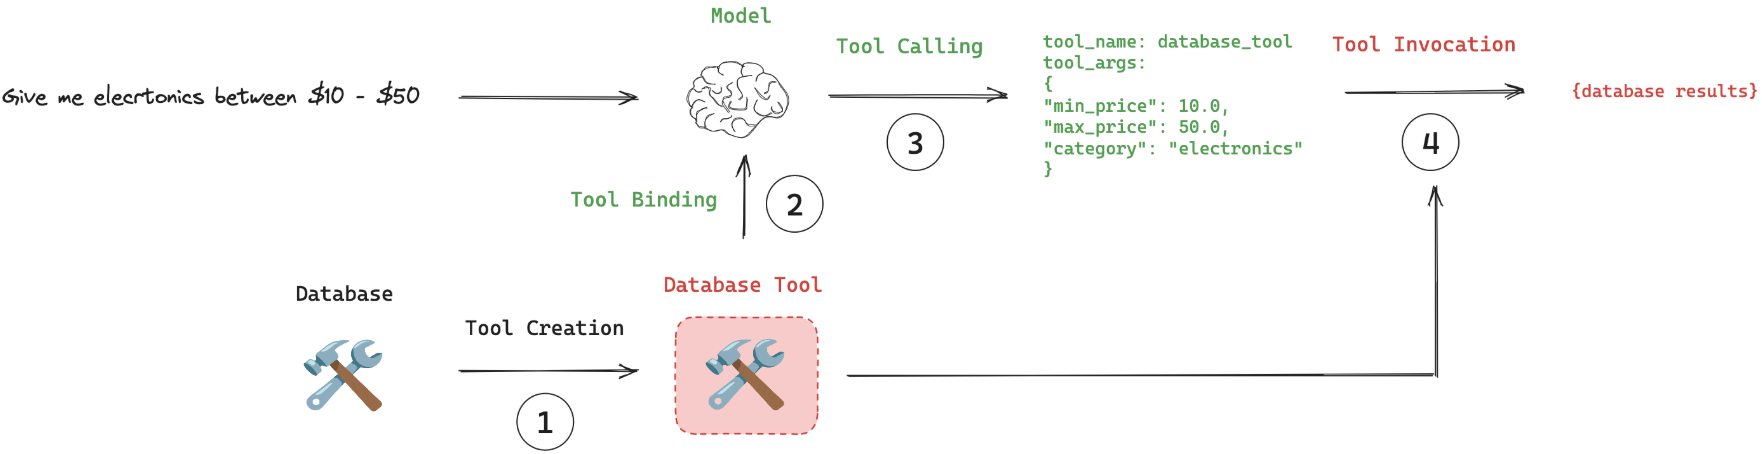

1. `도구 생성`: @tool 데코레이터를 사용하여 도구를 생성합니다 . 도구는 함수와 해당 스키마 간의 연결입니다.
2. `도구 바인딩`: 도구는 도구 호출을 지원하는 모델에 연결되어야 합니다. 이를 통해 모델이 도구와 도구에 필요한 관련 입력 스키마를 인식할 수 있습니다.
3. `도구 호출`: 적절한 경우 모델은 도구를 호출하고 해당 응답이 도구의 입력 스키마에 부합하는지 확인할 수 있습니다.
4. `도구 실행`: 도구는 모델이 제공한 인수를 사용하여 실행될 수 있습니다.

# Agents (에이전트)
- 여러 개의 Tools를 관리하고, 어떤 Tool을 어떤 순서로 사용할지 결정하는 역할을 담당합니다.

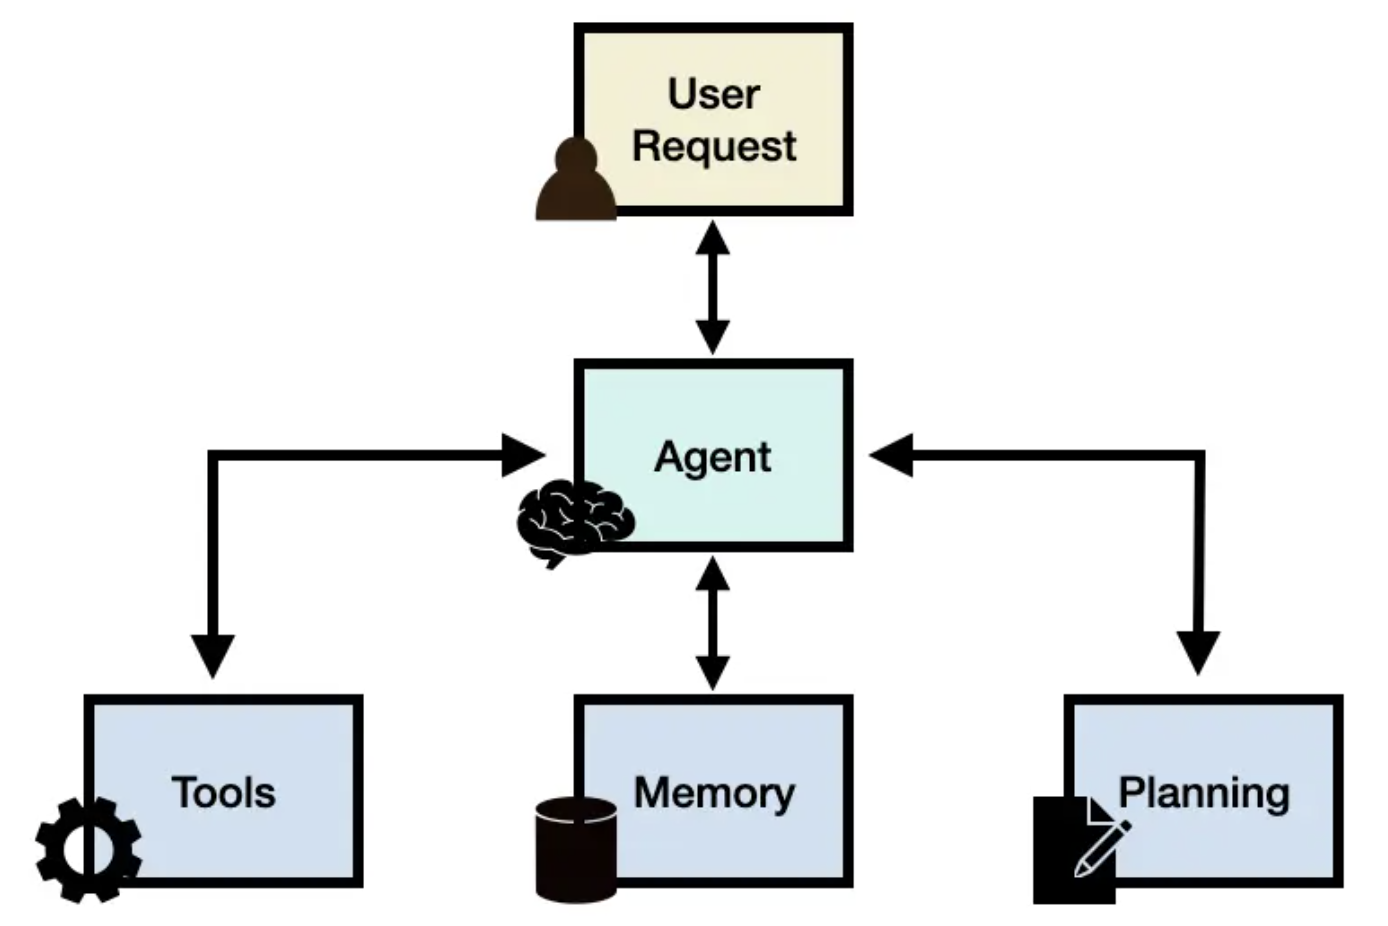

## Tools vs Agents
- Tools는 "LLM이 사용할 수 있는 도구"
- Agents는 "도구를 언제, 어떻게 사용할지 결정하는 지능"

# Python을 이용한 Tool 생성

### 1단계: Python 실행 도구

> subprocess는 파이썬에서 다른 프로그램을 실행할 수 있게 해주는 모듈

In [40]:
from langchain_core.tools import tool
import subprocess
import sys

@tool
def python_tool(code: str) -> str:
    """Python 코드를 실행합니다."""
    try:
        python_exec = "python3" if sys.platform != "win32" else "python"

        result = subprocess.run(
            [python_exec, "-c", code],  # 새로운 파이썬 프로세스 실행, -c는 "코드를 직접 실행"이라는 뜻
            capture_output=True,     # 실행 결과(출력)를 저장해서 가져옴
            text=True,               # 결과를 문자열로 받음 (False면 바이트로 받음)
            timeout=5                # 5초 안에 끝나지 않으면 강제 종료
        )
        return result.stdout if result.stdout else result.stderr
    except Exception as e:
        return f"오류: {str(e)}"

In [41]:
python_tool.invoke({"code":"print(2**10)"})

'1024\n'

In [42]:
print(2**10)

1024


In [43]:
python_tool.invoke({"code":"print(sum([i for i in range(1, 6)]))"})

'15\n'

In [44]:
print(sum([i for i in range(1, 6)]))

15


### 2단계: 그래프를 생성하는 도구

In [45]:
from langchain.tools import tool

@tool
def create_simple_plot(data: str) -> str:
    """간단한 데이터를 받아서 matplotlib으로 그래프를 생성합니다.
    data는 쉼표로 구분된 숫자 문자열이어야 합니다. 예: '1,2,3,4,5'
    """
    try:
        # 문자열을 숫자 리스트로 변환
        numbers = [float(x.strip()) for x in data.split(',')]
        
        # matplotlib 임포트 및 그래프 생성
        import matplotlib.pyplot as plt
        import koreanize_matplotlib
        import numpy as np
        
        plt.figure(figsize=(8, 6)) # 생성되는 그래프의 크기 
        plt.plot(numbers, marker='o') # 그래프 생성 
        plt.title('데이터 시각화') # 그래프의 이름 
        plt.xlabel('인덱스') # x축에 대한 이름 
        plt.ylabel('값') # y축에 대한 이름 
        plt.grid(True)
        plt.show()
        
        return f"그래프가 생성되었습니다. 데이터 포인트: {len(numbers)}개"
    except Exception as e:
        return f"그래프 생성 중 오류가 발생했습니다: {str(e)}"

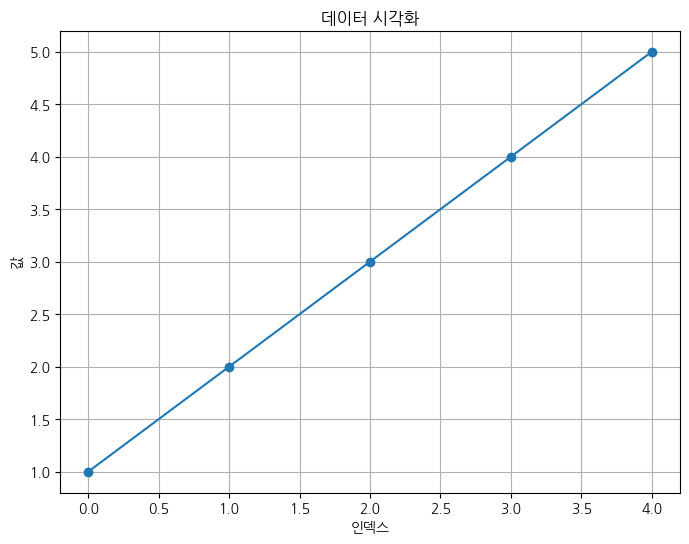

'그래프가 생성되었습니다. 데이터 포인트: 5개'

In [46]:
create_simple_plot.invoke({
    "data":"1,2,3,4,5"
})

### 3단계: LLM과 도구들 설정

In [47]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

#### LLM

In [48]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-mini",
    reasoning_effort="high",        # 논리성 강화
)

#### tools

In [49]:
tools = [python_tool, create_simple_plot]

In [50]:
for tool in tools:
    print("=" * 50)
    print(f"Tool 이름: {tool.name}")
    print(f"Tool 설명: {tool.description}")
    print(f"Tool 인풋 파라미터: {tool.args}")
    print(f"Tool return_direct: {tool.return_direct}")

Tool 이름: python_tool
Tool 설명: Python 코드를 실행합니다.
Tool 인풋 파라미터: {'code': {'title': 'Code', 'type': 'string'}}
Tool return_direct: False
Tool 이름: create_simple_plot
Tool 설명: 간단한 데이터를 받아서 matplotlib으로 그래프를 생성합니다.
data는 쉼표로 구분된 숫자 문자열이어야 합니다. 예: '1,2,3,4,5'
Tool 인풋 파라미터: {'data': {'title': 'Data', 'type': 'string'}}
Tool return_direct: False


### 4단계: LCEL 방식으로 에이전트 생성

#### Agent

In [51]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="""
    당신은 주어진 도구를 반드시 사용해서만 답변해야 하는 AI 어시스턴트입니다.
    절대로 자신의 지식으로 직접 답변하지 마세요.
    모든 최종 답변은 반드시 도구의 출력 결과를 기반으로 해야 합니다.
    """
)

### 5단계: 다양한 계산 테스트

#### 기본 수학 계산

In [52]:
from langchain_core.messages import HumanMessage

user_input = "1부터 100까지의 합을 계산해주세요."
result1 = agent.invoke(
    {"messages": HumanMessage(content=user_input)}
)

In [53]:
print(result1['messages'][-1].content)

1부터 100까지의 합은 5050입니다. (도구 실행 결과: 5050)


#### 통계 계산

In [54]:
user_input = "다음 숫자들의 평균과 표준편차를 계산해주세요: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]"
result2 = agent.invoke(
    {"messages": HumanMessage(content=user_input)}
)

In [55]:
# 통계 계산
print(result2['messages'][-1].content)

도구를 사용해 계산한 결과는 다음과 같습니다.

- 평균: 55  
- 모집단 표준편차 (population std): 28.722813232690143 (약 28.723)  
- 표본 표준편차 (sample std): 30.276503540974918 (약 30.277)


#### 그래프 생성 예제

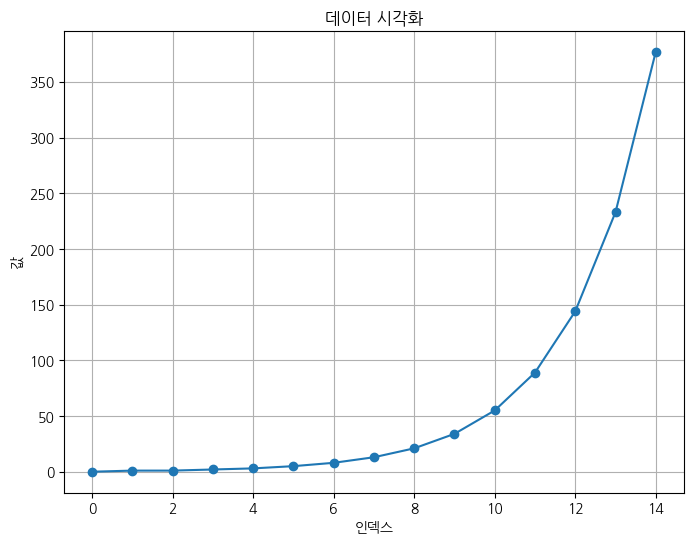

In [56]:
user_input = "피보나치 수열 처음 15개를 계산해서 그래프로 그려줘"
graph_result = agent.invoke(
    {"messages": HumanMessage(content=user_input)}
)

In [57]:
# 그래프 생성 예제
print(graph_result['messages'][-1].content)

요청하신 피보나치 수열(처음 15개)을 계산하고 그래프로 그렸습니다.

- CSV: 0,1,1,2,3,5,8,13,21,34,55,89,144,233,377
- 리스트: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]

그래프가 생성되었습니다. 데이터 포인트: 15개

원하시면 그래프를 PNG로 저장하거나 축 레이블/스타일을 변경해 다시 만들어 드리겠습니다. 어느 작업을 원하시나요?


#### 고급 예제: 데이터 분석과 시각화

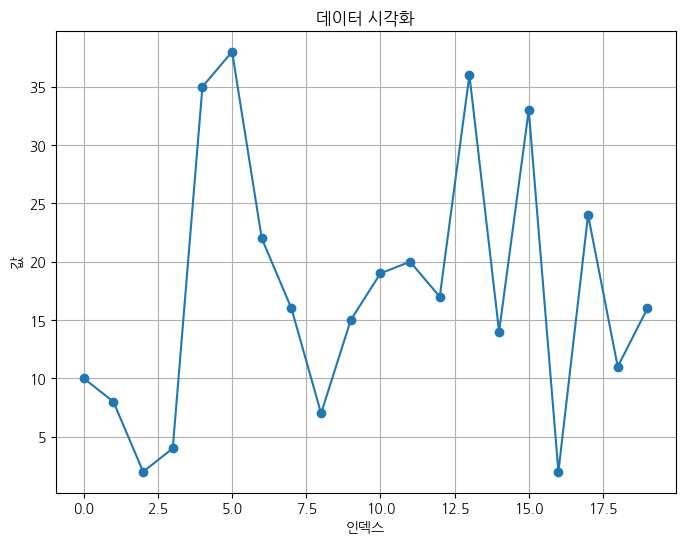

In [58]:
user_input = """
    다음 작업을 순서대로 해주세요:
    1. 1부터 50까지 랜덤한 숫자 20개를 생성
    2. 이 숫자들의 평균, 중간값, 최댓값, 최솟값 계산
    3. 히스토그램 생성 (matplotlib 사용) 후 주피터에서 확인할 수 있도록 만들어줘.
    4. 결과를 정리해서 보고해주세요
"""
analysis_result = agent.invoke(
    {"messages": HumanMessage(content=user_input)}
)

In [59]:
# 고급 예제: 데이터 분석과 시각화
print(analysis_result['messages'][-1].content)

요청하신 작업을 수행했습니다. 도구 출력 결과를 기반으로 정리한 내용은 다음과 같습니다.

1) 생성된 랜덤 숫자 20개
[10, 8, 2, 4, 35, 38, 22, 16, 7, 15, 19, 20, 17, 36, 14, 33, 2, 24, 11, 16]

2) 계산된 통계값
- 평균(mean): 17.45  
- 중간값(median): 16.0  
- 최솟값(min): 2  
- 최댓값(max): 38

3) 히스토그램 생성
- matplotlib으로 히스토그램을 생성했습니다. 도구 응답: "그래프가 생성되었습니다. 데이터 포인트: 20개"  
- 재현용 데이터 문자열 (Jupyter에 복사/붙여넣기 가능):  
  "10,8,2,4,35,38,22,16,7,15,19,20,17,36,14,33,2,24,11,16"

4) 간단 요약
- 표본(20개)의 평균은 17.45, 중앙값은 16.0으로 중앙값이 평균보다 작아 큰 값 쪽으로 일부 편향이 있을 수 있습니다.  
- 값의 범위는 최솟값 2에서 최댓값 38까지입니다.  
- 히스토그램은 위에서 생성되었으니 Jupyter 노트북에서 확인하실 수 있습니다(도구가 그래프를 생성했다고 응답함).

원하시면:
- 히스토그램을 PNG 등 파일로 저장해서 드리거나,  
- Jupyter 셀에 바로 붙여넣어 실행 가능한 matplotlib 코드(히스토그램 재현용)를 생성해 드리겠습니다.  
어떤 형태로 받으시길 원하시는지 알려주세요.


## [Langsmith에서 확인하기](https://smith.langchain.com/)

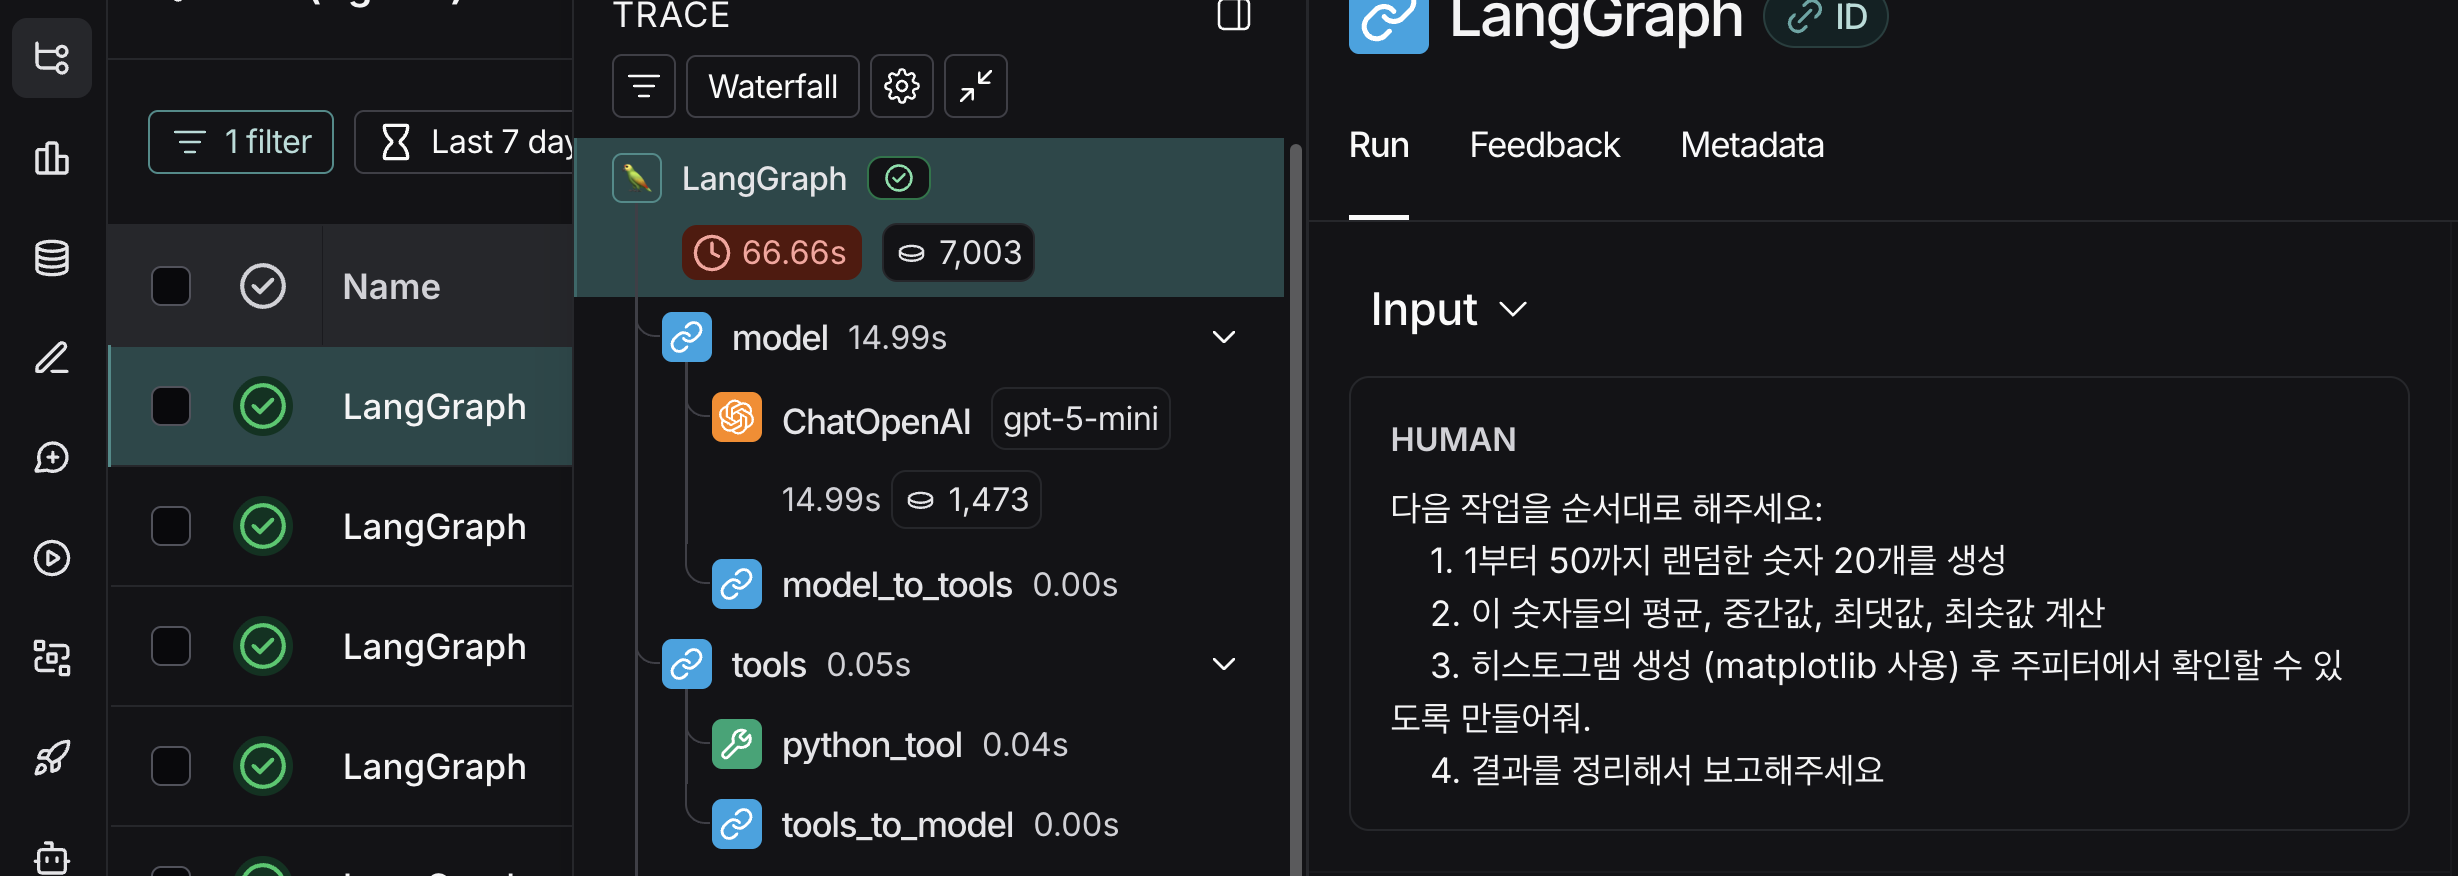